In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("credit_risk_dataset.csv")

# Display first 5 rows
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("credit_risk_dataset.csv")
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (32581, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.5 MB


In [4]:
# Missing values
print(df.isnull().sum())

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [5]:
# Check missing values before cleaning

print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [6]:
# Fill missing numerical values with median

df["person_emp_length"] = df["person_emp_length"].fillna(
    df["person_emp_length"].median()
)

df["loan_int_rate"] = df["loan_int_rate"].fillna(
    df["loan_int_rate"].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 165


In [8]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (32416, 12)


In [9]:
print(df["loan_status"].value_counts())

loan_status
0    25327
1     7089
Name: count, dtype: int64


In [10]:
print(df["loan_status"].value_counts(normalize=True) * 100)

loan_status
0    78.13117
1    21.86883
Name: proportion, dtype: float64


In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32416.000000,3.241600e+04,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000,32416.000000
mean,27.747008,6.609164e+04,4.768880,9593.845632,11.014662,0.218688,0.170250,5.811297
std,6.354100,6.201558e+04,4.090411,6322.730241,3.083050,0.413363,0.106812,4.059030
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.854200e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.921800e+04,7.000000,12250.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
print("Home Ownership:")
print(df["person_home_ownership"].value_counts())

print("\nLoan Intent:")
print(df["loan_intent"].value_counts())

print("\nLoan Grade:")
print(df["loan_grade"].value_counts())

print("\nPrevious Default:")
print(df["cb_person_default_on_file"].value_counts())

Home Ownership:
person_home_ownership
RENT        16378
MORTGAGE    13369
OWN          2563
OTHER         106
Name: count, dtype: int64

Loan Intent:
loan_intent
EDUCATION            6411
MEDICAL              6042
VENTURE              5682
PERSONAL             5498
DEBTCONSOLIDATION    5189
HOMEIMPROVEMENT      3594
Name: count, dtype: int64

Loan Grade:
loan_grade
A    10703
B    10387
C     6438
D     3620
E      963
F      241
G       64
Name: count, dtype: int64

Previous Default:
cb_person_default_on_file
N    26686
Y     5730
Name: count, dtype: int64


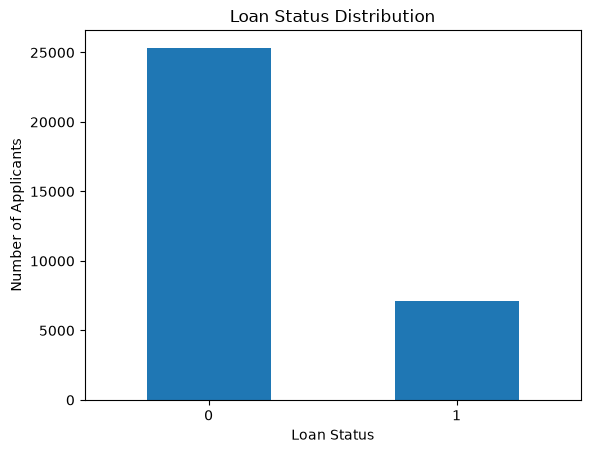

In [13]:
import matplotlib.pyplot as plt

df["loan_status"].value_counts().plot(kind="bar")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")
plt.xticks(rotation=0)
plt.show()

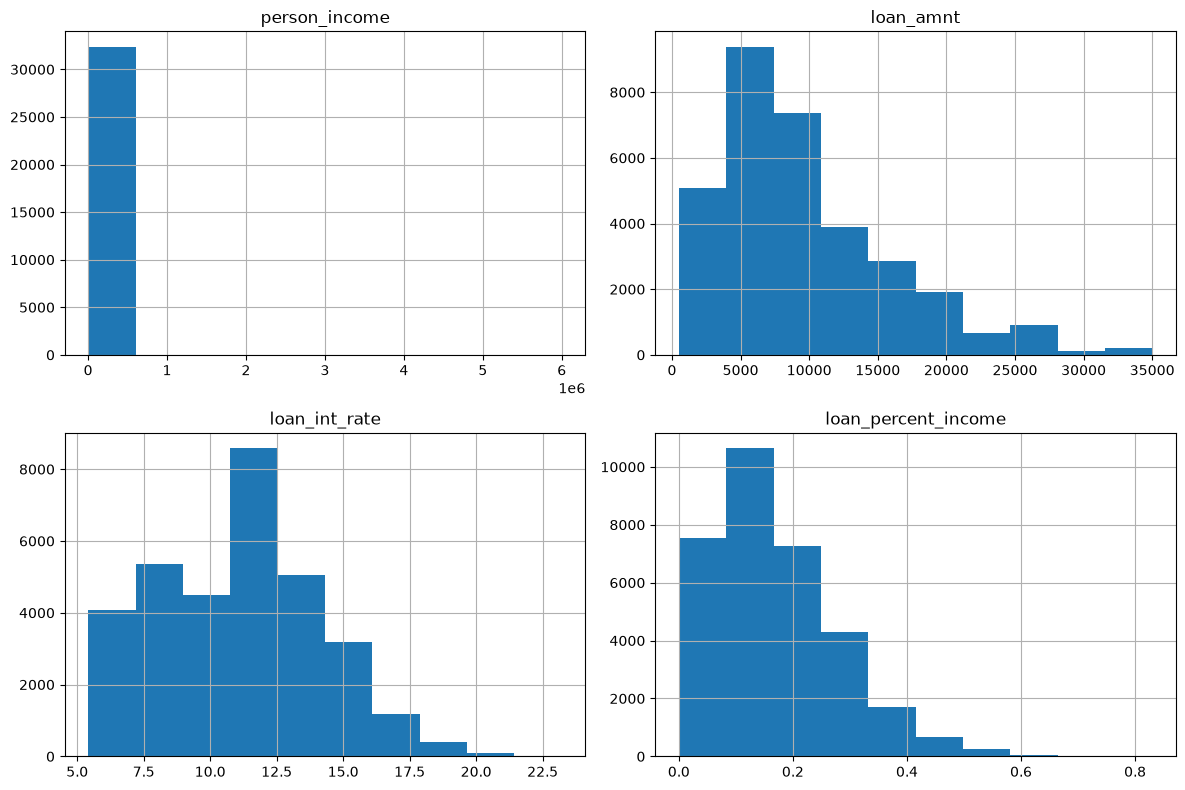

In [14]:
df[["person_income", "loan_amnt", "loan_int_rate", 
    "loan_percent_income"]].hist(figsize=(12, 8))

plt.tight_layout()
plt.show()

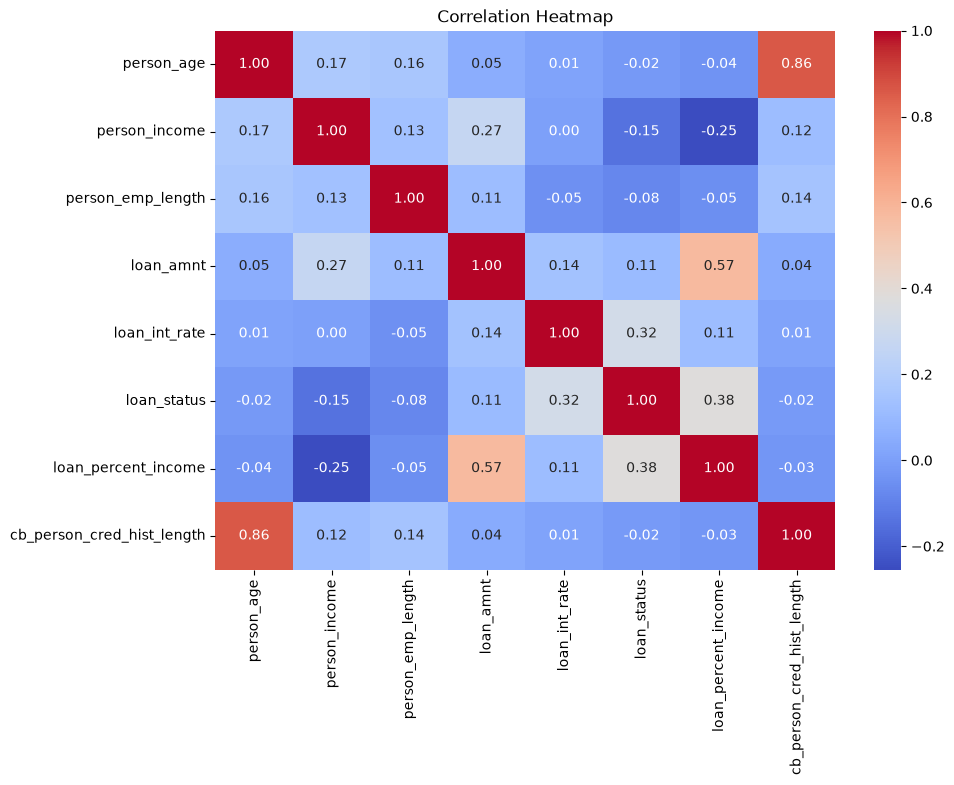

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
df["income_to_loan_ratio"] = df["person_income"] / df["loan_amnt"]

In [17]:
df["loan_burden"] = pd.cut(
    df["loan_percent_income"],
    bins=[0, 0.2, 0.4, 0.6, 1.0],
    labels=["Low", "Medium", "High", "Very High"]
)

In [18]:
df["age_group"] = pd.cut(
    df["person_age"],
    bins=[0, 25, 35, 50, 100],
    labels=["Young", "Adult", "Middle-aged", "Senior"]
)

In [19]:
df["credit_history_ratio"] = (
    df["cb_person_cred_hist_length"] / df["person_age"]
)

In [20]:
print(df.columns.tolist())

['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'income_to_loan_ratio', 'loan_burden', 'age_group', 'credit_history_ratio']


In [21]:
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,income_to_loan_ratio,loan_burden,age_group,credit_history_ratio
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,1.685714,High,Young,0.136364
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.600000,Low,Young,0.095238
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,1.745455,High,Young,0.120000
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,1.871429,High,Young,0.086957
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,1.554286,High,Young,0.166667


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Separate features and target
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'income_to_loan_ratio', 'credit_history_ratio']

Categorical features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_burden', 'age_group']


C:\Users\HP\AppData\Local\Temp\ipykernel_27588\4086655418.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (25932, 15)
Testing data: (6484, 15)


In [24]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [25]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nNumerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Training data: (25932, 15)
Testing data: (6484, 15)

Numerical features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'income_to_loan_ratio', 'credit_history_ratio']

Categorical features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file', 'loan_burden', 'age_group']


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# ============================================================
# 1. LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)


# ============================================================
# 2. DECISION TREE
# ============================================================

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            max_depth=10,
            class_weight="balanced",
            random_state=42
        ))
    ]
)


# ============================================================
# 3. RANDOM FOREST
# ============================================================

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)


# ============================================================
# TRAIN MODELS
# ============================================================

print("Training Logistic Regression...")
logistic_model.fit(X_train, y_train)

print("Training Decision Tree...")
decision_tree_model.fit(X_train, y_train)

print("Training Random Forest...")
random_forest_model.fit(X_train, y_train)

print("\nAll models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

All models trained successfully!


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability for ROC-AUC
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.816626,0.558568,0.770099,0.647495,0.869611
1,Decision Tree,0.891425,0.746888,0.761636,0.754190,0.903959
2,Random Forest,0.931370,0.955951,0.719323,0.820926,0.929177


Confusion Matrix:
[[5019   47]
 [ 398 1020]]


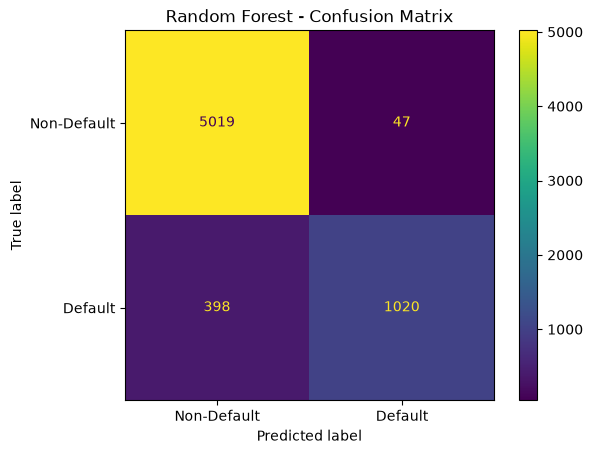

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions from Random Forest
y_pred_rf = random_forest_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

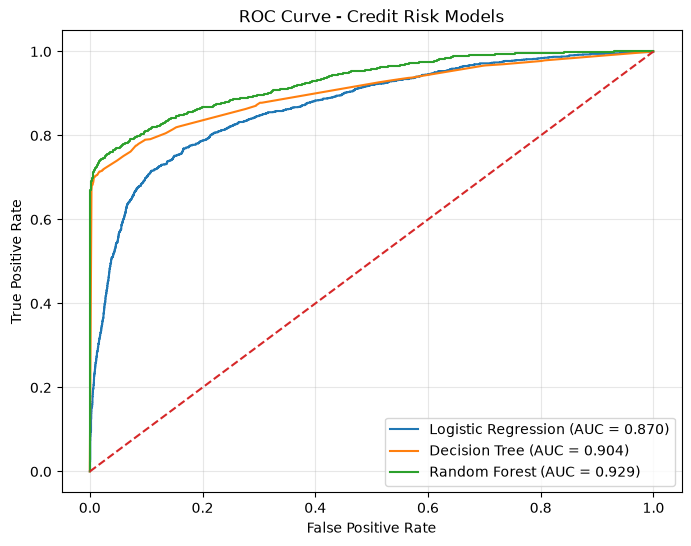

In [29]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_probability = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_probability)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Risk Models")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the trained Random Forest classifier
rf_classifier = random_forest_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance
importance = rf_classifier.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15 features
display(feature_importance_df.head(15))

,Feature,Importance
7,num__income_to_loan_ratio,0.129723
4,num__loan_int_rate,0.127205
1,num__person_income,0.113479
5,num__loan_percent_income,0.101580
22,cat__loan_grade_D,0.064870
3,num__loan_amnt,0.047851
12,cat__person_home_ownership_RENT,0.043034
29,cat__loan_burden_Low,0.039703
2,num__person_emp_length,0.032270
19,cat__loan_grade_A,0.026899


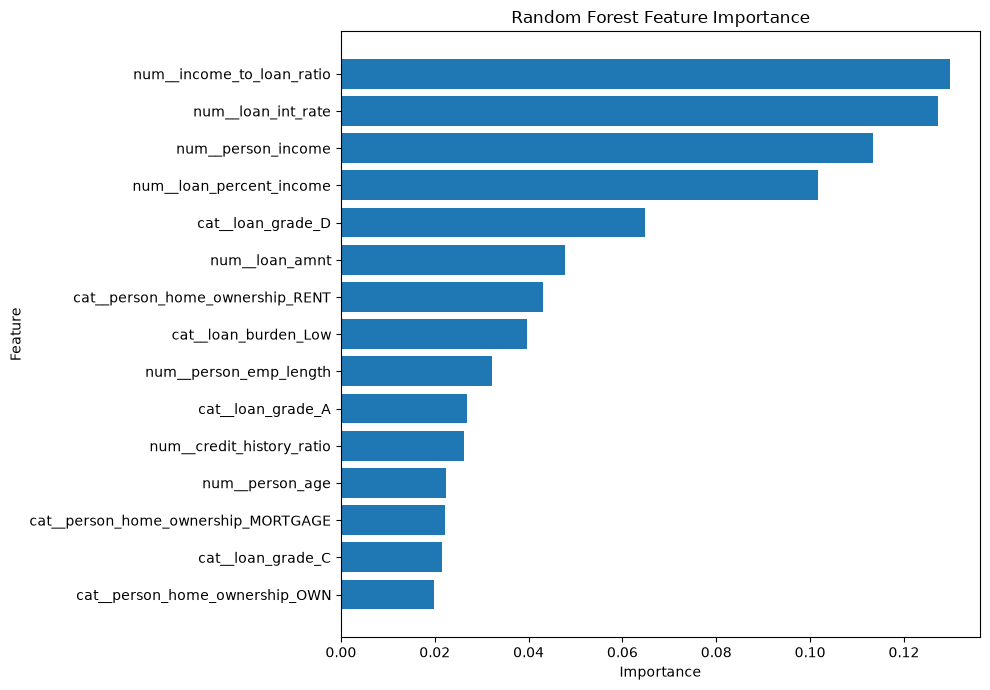

In [31]:
plt.figure(figsize=(10, 7))

top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Get Random Forest classifier
rf_classifier = random_forest_model.named_steps["classifier"]

# Get feature names after preprocessing
feature_names = random_forest_model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get feature importance
importance = rf_classifier.feature_importances_

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display top 15
display(feature_importance_df.head(15))

,Feature,Importance
7,num__income_to_loan_ratio,0.129723
4,num__loan_int_rate,0.127205
1,num__person_income,0.113479
5,num__loan_percent_income,0.101580
22,cat__loan_grade_D,0.064870
3,num__loan_amnt,0.047851
12,cat__person_home_ownership_RENT,0.043034
29,cat__loan_burden_Low,0.039703
2,num__person_emp_length,0.032270
19,cat__loan_grade_A,0.026899


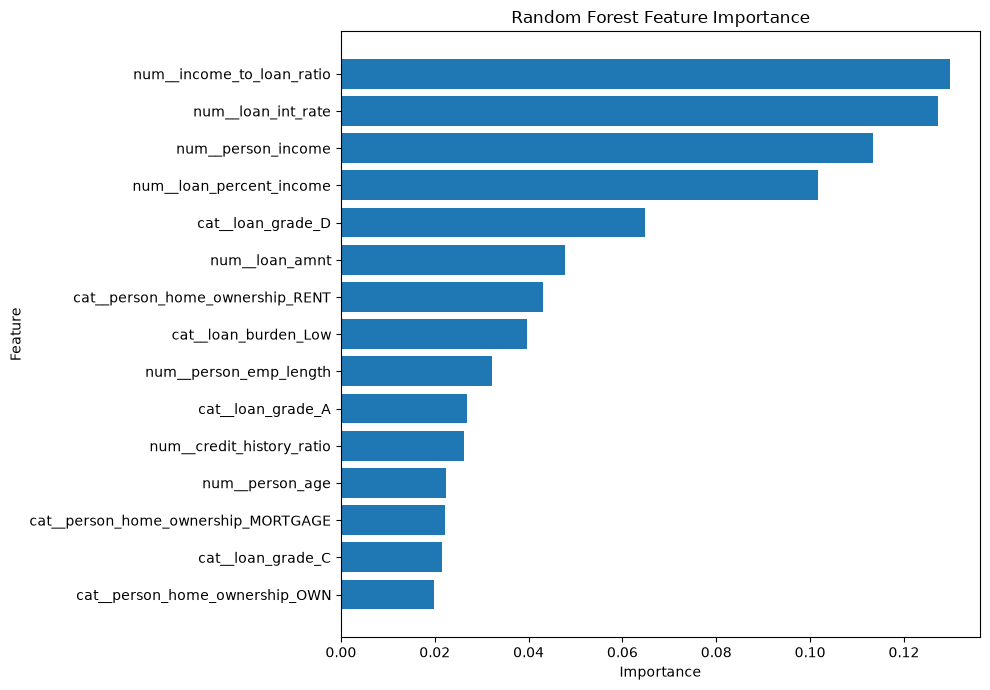

In [33]:
plt.figure(figsize=(10, 7))

top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [34]:
import joblib

# Save the complete Random Forest pipeline
joblib.dump(random_forest_model, "credit_risk_random_forest.pkl")

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [35]:
import pandas as pd

new_applicant = pd.DataFrame({
    "person_age": [30],
    "person_income": [60000],
    "person_home_ownership": ["RENT"],
    "person_emp_length": [5],
    "loan_intent": ["PERSONAL"],
    "loan_grade": ["B"],
    "loan_amnt": [10000],
    "loan_int_rate": [11.5],
    "loan_percent_income": [0.17],
    "cb_person_default_on_file": ["N"],
    "cb_person_cred_hist_length": [6],
    "income_to_loan_ratio": [6.0],
    "loan_burden": ["Low"],
    "age_group": ["Adult"],
    "credit_history_ratio": [0.20]
})

print(new_applicant)

   person_age  person_income person_home_ownership  person_emp_length  \
0          30          60000                  RENT                  5   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_percent_income  \
0    PERSONAL          B      10000           11.5                 0.17   

  cb_person_default_on_file  cb_person_cred_hist_length  income_to_loan_ratio  \
0                         N                           6                   6.0   

  loan_burden age_group  credit_history_ratio  
0         Low     Adult                   0.2  


In [36]:
prediction = random_forest_model.predict(new_applicant)[0]

probability = random_forest_model.predict_proba(new_applicant)[0]

print("Prediction:", prediction)
print("Non-Default Probability:", probability[0])
print("Default Probability:", probability[1])

Prediction: 0
Non-Default Probability: 0.8462532852817928
Default Probability: 0.15374671471820775


In [37]:
if prediction == 0:
    print("Credit Risk Result: LOW RISK / NON-DEFAULT")
else:
    print("Credit Risk Result: HIGH RISK / DEFAULT")

Credit Risk Result: LOW RISK / NON-DEFAULT


In [38]:
def predict_credit_risk(applicant_data):

    prediction = random_forest_model.predict(applicant_data)[0]

    probabilities = random_forest_model.predict_proba(applicant_data)[0]

    non_default_probability = probabilities[0]
    default_probability = probabilities[1]

    if prediction == 0:
        result = "LOW RISK / NON-DEFAULT"
    else:
        result = "HIGH RISK / DEFAULT"

    return {
        "Prediction": result,
        "Non-Default Probability": non_default_probability,
        "Default Probability": default_probability
    }

In [39]:
result = predict_credit_risk(new_applicant)

print(result)

{'Prediction': 'LOW RISK / NON-DEFAULT', 'Non-Default Probability': np.float64(0.8462532852817927), 'Default Probability': np.float64(0.15374671471820778)}
